# Credit Card Fraud Detection using TensorFlow

## Introduction

Credit card fraud is one of the most common financial crimes in today's digital world. Detecting fraudulent transactions quickly is essential to reduce financial losses and protect customers. In this project, a deep learning model is developed using TensorFlow and Keras to classify credit card transactions as either legitimate or fraudulent. The dataset is preprocessed, the model is trained, evaluated, and the results are analyzed using various performance metrics.

## Import Required Libraries

The required Python libraries are imported to perform data manipulation, visualization, machine learning, and deep learning. Pandas and NumPy are used for data processing, Matplotlib is used for visualization, TensorFlow is used to build the neural network model, and Scikit-learn provides tools for preprocessing, splitting the dataset, and evaluating the model.

In [13]:
# Import Libraries

import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [14]:
# Import Machine Learning Utilities

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

## Load the Dataset

The credit card transaction dataset is loaded into a Pandas DataFrame using the `read_csv()` function. After loading the data, the first few records, dataset dimensions, column information, and class distribution are displayed to understand the structure of the dataset.

In [53]:
# Load Dataset

df = pd.read_csv(r"C:\Users\rrama_t5uaug6\Downloads\archive (12)\creditcard.csv")

print(df.head())

print(df.shape)

print(df.info())

print(df['Class'].value_counts())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

This line loads the CSV file into a Pandas DataFrame.

The r before the file path tells Python to treat backslashes (\) as literal characters.

## Data Preprocessing

The dataset is prepared for model training by separating the input features and the target variable. The Time and Amount columns are standardized using StandardScaler so that all features have a similar scale. This improves the training performance of the neural network.


In [12]:
# Features and Target

X = df.drop("Class", axis=1)
y = df["Class"]

The dataset has:

Input features (X)
Target variable (y)

In [17]:
# Scale Amount and Time

scaler = StandardScaler()

X[['Time', 'Amount']] = scaler.fit_transform(X[['Time', 'Amount']])

Neural networks perform better when numerical features are on a similar scale.

StandardScaler transforms values so they have:
Mean ≈ 0
Standard deviation ≈ 1

## Split the Dataset

The dataset is divided into training and testing sets using an 80:20 ratio. The training set is used to train the neural network, while the testing set is used to evaluate its performance on unseen data. Stratified sampling is applied to preserve the class distribution.

In [21]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape)
print(X_test.shape)

(227845, 30)
(56962, 30)


The data is divided into:

80% Training data
20% Testing data

## Build the TensorFlow Neural Network

A Sequential neural network is created using TensorFlow and Keras. The model consists of multiple dense layers with ReLU activation functions and Dropout layers to reduce overfitting. The final output layer uses a sigmoid activation function to predict whether a transaction is fraudulent or legitimate.

In [26]:
# Build Neural Network

model = tf.keras.Sequential([

    tf.keras.Input(shape=(X_train.shape[1],)),

    tf.keras.layers.Dense(
        64,
        activation='relu'),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        32,
        activation='relu'),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        16,
        activation='relu'),

    tf.keras.layers.Dense(
        1,
        activation='sigmoid')])

Sequential creates a neural network where layers are arranged one after another.

## Compile the Model

The model is compiled using the Adam optimizer, binary cross-entropy loss function, and accuracy as the evaluation metric. These settings are suitable for binary classification problems such as fraud detection.

In [30]:
# Compile Model

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

Optimizer (adam) updates the model weights to minimize the loss.
    
Loss (binary_crossentropy) measures prediction error for binary classification.
    
Accuracy tracks the percentage of correct predictions during training.

## Train the Model

The neural network is trained using the training dataset for multiple epochs. During training, a portion of the training data is used as validation data to monitor the model's performance and detect overfitting.

In [32]:
# Train

history = model.fit(X_train, y_train, epochs=20, batch_size=64, validation_split=0.2)

Epoch 1/20
2849/2849 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9971 - loss: 0.0127 - val_accuracy: 0.9994 - val_loss: 0.0037
Epoch 2/20
2849/2849 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9993 - loss: 0.0040 - val_accuracy: 0.9994 - val_loss: 0.0032
Epoch 3/20
2849/2849 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9993 - loss: 0.0036 - val_accuracy: 0.9994 - val_loss: 0.0032
Epoch 4/20
2849/2849 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9994 - loss: 0.0034 - val_accuracy: 0.9994 - val_loss: 0.0030
Epoch 5/20
2849/2849 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9994 - loss: 0.0031 - val_accuracy: 0.9993 - val_loss: 0.0030
Epoch 6/20
2849/2849 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9993 - loss: 0.0031 - val_accuracy: 0.9994 - val_loss: 0.0032
Epoch 7/20
2849/2849 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9994 - loss: 0.0029 - val_accuracy: 0.9994 - val_loss: 0.0031
Epoch 8/20
2849/2849 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.9994 - loss: 0.0

Parameters:

epochs=20 - The model processes the full training dataset 20 times.
    
batch_size=64 -  The model updates its weights after every 64 samples.
    
validation_split=0.2 - 20% of the training data is used to monitor performance during training.

## Evaluate the Model

After training, the model is evaluated using the testing dataset. The evaluation provides the loss and accuracy values, which indicate how well the model performs on unseen data.

In [35]:
# Evaluate

loss, accuracy = model.evaluate(X_test, y_test)

print("Loss :", loss)
print("Accuracy :", accuracy)

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9993 - loss: 0.0030
Loss : 0.0029993948992341757
Accuracy : 0.9992802143096924


The model is tested on data it has never seen before.

It returns:

Loss: Prediction error.
    
Accuracy: Percentage of correctly classified transactions.

## Make Predictions

The trained model predicts whether each transaction in the testing dataset is fraudulent or legitimate. A threshold value of 0.5 is used to convert probabilities into binary class labels.

In [39]:
# Prediction

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


The model first predicts probabilities (values between 0 and 1).

Using a threshold of 0.5:

Probability > 0.5 - Classified as fraud (1)

Probability ≤ 0.5 - Classified as legitimate (0)

## Model Evaluation

The confusion matrix and classification report are generated to evaluate the model's prediction performance. These metrics provide insights into the model's precision, recall, F1-score, and overall classification accuracy.

In [55]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)
print(classification_report(y_test, y_pred))

[[56846    18]
 [   23    75]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.81      0.77      0.79        98

    accuracy                           1.00     56962
   macro avg       0.90      0.88      0.89     56962
weighted avg       1.00      1.00      1.00     56962



This report provides detailed evaluation metrics:

Precision → Of the transactions predicted as fraud, how many were actually fraud

Recall → Of all actual fraud cases, how many did the model detect

F1-score → The balance between Precision and Recall.
    
Support → The number of samples in each class.

## Visualize the Results

Training and validation accuracy and loss graphs are plotted to visualize the learning process. These graphs help determine whether the model is learning effectively and whether overfitting has occurred.

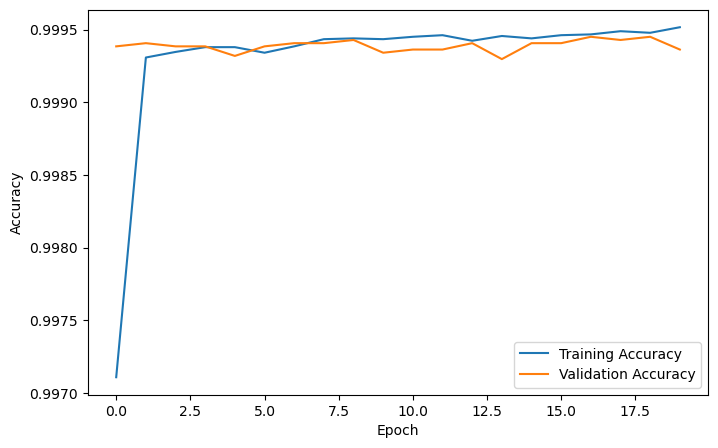

In [56]:
# Accuracy Graph

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

This graph compares:

Training Accuracy: How well the model learns from the training data.
    
Validation Accuracy: How well the model performs on unseen validation data.

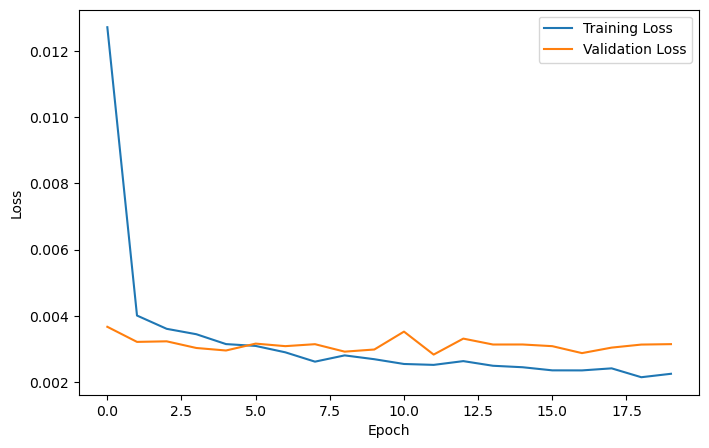

In [57]:
# Loss Graph

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

This graph shows how the prediction error changes over training.

A good model generally has:

Decreasing training loss.
    
Decreasing validation loss.
    
Similar trends for both curves, indicating good generalization.

## Save the Trained Model

The trained TensorFlow model is saved so that it can be loaded later without retraining. This allows the model to be reused for future predictions or deployment.

In [60]:
model.save("credit_card_fraud_detection.keras")
print("Model saved successfully!")

Model saved successfully!


## Conclusion

In this project, I developed a credit card fraud detection model using TensorFlow and Keras. I started by loading and preprocessing the dataset, which included scaling the necessary features and splitting the data into training and testing sets. A deep neural network with multiple dense layers and dropout was then built and trained to classify transactions as either legitimate or fraudulent.

After training, the model was evaluated using accuracy, a confusion matrix, and a classification report to measure its performance. The results showed that the model was able to learn meaningful patterns from the data and make predictions on unseen transactions. This project also highlighted the importance of proper data preprocessing and model evaluation when working with real-world financial data.

Overall, this project strengthened my understanding of TensorFlow, neural networks, and binary classification. In the future, the model could be further improved by handling the class imbalance more effectively using techniques such as class weights or SMOTE, and by evaluating additional metrics like ROC-AUC to achieve even better fraud detection performance.